<a href="https://colab.research.google.com/github/mobadara/finbert-sentiment-analyzer-api/blob/main/notebooks/01_eda_and_data_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FINANCIAL NEWS SENTIMENT ANALYSIS**
## 📈 **EDA & Data Engineering**


**Author:** [Muyiwa J. Obadara](https://portfolio-frontend-livid.vercel.app)

**Project:** FinBERT Sentiment API Backend

### **Objective**
The goal of this notebook is to perform Exploratory Data Analysis (EDA) and preprocess the **[Financial PhraseBank](https://huggingface.co/datasets/FinanceMTEB/financial_phrasebank)** dataset. Financial text is highly specialized; words that represent positive sentiment in a general context might represent risk in a financial context.

By analyzing the class distributions and cleaning the text, we will create a highly optimized dataset ready to fine-tune the `ProsusAI/finbert` model in the next phase of this pipeline.

### **Dataset Details**
* **Source:** `financial_phrasebank` (via Hugging Face Datasets)
* **Configuration:** `sentences_allagree` (Using only sentences where 100% of human annotators agreed on the sentiment)
* **Labels:** 0 (Negative), 1 (Neutral), 2 (Positive)

### **Setup**

In [12]:
from datasets import load_dataset
try:
    from google.colab import userdata
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
import shutil
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['blue'])

In [2]:
os.makedirs('figures', exist_ok=True)
os.makedirs('datasets', exist_ok=True)

In [3]:
dataset = load_dataset('FinanceMTEB/financial_phrasebank')

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label_text', 'label'],
        num_rows: 1264
    })
    test: Dataset({
        features: ['text', 'label_text', 'label'],
        num_rows: 1000
    })
})

The dataset has two splits:
1. Train Dataset contains 1264 instances.
2. Test Dataset contains 1000 instances.

We need to convert the train dataset to a pandas datafrome exploration.

In [5]:
df_train = dataset['train'].to_pandas()
df_train.head()

,text,label_text,label
0,The Samsung Mobile Applications Store was laun...,neutral,1
1,"F-Secure , a developer of security solutions a...",neutral,1
2,The company serves customers in various indust...,neutral,1
3,The company reported net sales of 302 mln euro...,neutral,1
4,Microsoft last week also issued the first patc...,neutral,1


### **Data Check and Cleaning**

In [6]:
# Check for `null` values
nulls_per_column = df_train.isna().sum()

# Check for duplicated values
duplicated_instances = df_train.duplicated().sum()

print("Null Values Per Column:")
print(nulls_per_column)
print("-" * 30)
print(f"Number of Duplicated Instances: {duplicated_instances}")

Null Values Per Column:
text          0
label_text    0
label         0
dtype: int64
------------------------------
Number of Duplicated Instances: 1


We see that our dataset (in tabular form) contains three columns: **text**, **label_text** and **label**.

The **`label_text`** has three unique represents the sentiments of each text in human redable form, which are **positive**, **negative** or **neutral**.

Each of this is encoded in the `label` as follows:
label_text | code
-----------|-----
negative   | `0`
neutral    | `1`
positive   | `1`


We see from our result that one instance in the dataset is exactly repeated. We drop the duplicated values in the following cell.

In [7]:
df_train.drop_duplicates(inplace=True)
assert df_train.duplicated().sum() == 0

Now that the duplicated entries are removed, we need to visualize our class distribution.

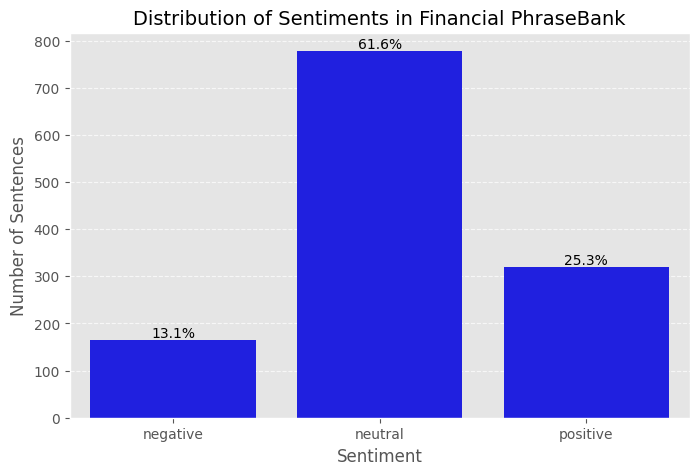

In [8]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_train,
              x='label_text',
              order=['negative', 'neutral', 'positive'])
plt.title('Distribution of Sentiments in Financial PhraseBank', fontsize=14)
plt.ylabel('Number of Sentences', fontsize=12)
plt.xlabel('Sentiment', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentages on top of each bar
total = len(df_train)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.savefig('figures/class_distribution.png')
plt.show()

Now that we understand our dataset and we have cleaned it, we need to save the cleaned dataset for future use.

In [9]:
df_train.to_csv('datasets/df_train_cleaned.csv')

The following cell will only run if woring in colab.

In [13]:
if IN_COLAB:
    try:
        GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
    except userdata.SecretNotFoundError:
        raise ValueError('Please add a secrete named `GITHUB_TOKEN` to your colab secrets.')
    USER_NAME = 'mobadara'
    USER_EMAIL = 'muyiwa.j.obadara@gmail.com'
    REPO_NAME = 'finbert-sentiment-analyzer-api'
    if os.path.exists(REPO_NAME):
        print(f"Removing existing directory: {REPO_NAME}...")
        shutil.rmtree(REPO_NAME)
        print("Directory removed successfully.")
    else:
        print("No existing directory found. Proceeding straight to cloning.")

    # 2. Configure Git globally in the Colab environment
    !git config --global user.name 'mobadara'
    !git config --global user.email 'muyiwa.j.obadara@gmail.com'

    !git clone https://{GITHUB_TOKEN}@github.com/mobadara/finbert-sentiment-analyzer-api.git
else:
    print('Cell skipped.')

Removing existing directory: finbert-sentiment-analyzer-api...
Directory removed successfully.
Cloning into 'finbert-sentiment-analyzer-api'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 86 (delta 36), reused 16 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 92.54 KiB | 1.93 MiB/s, done.
Resolving deltas: 100% (36/36), done.


### **Add new files to the repositoy**

In [21]:
if IN_COLAB:
    try:
        shutil.move('datasets/cleaned_financial_phrasebank.csv', f'{REPO_NAME}/datasets')
    except Exception as e:
        print(f"Error moving the file: \n\t{e}")

    try:
        shutil.move('figures/class_distribution.png', f'{REPO_NAME}/figures')
    except Exception as e:
        print(f"Error moving the file: \n\t{e}")
    print(f"Files successfully moved into the {REPO_NAME} repository!")
else:
    print('Cell skipped.')

Error moving the file: 
	Destination path 'finbert-sentiment-analyzer-api/datasets/cleaned_financial_phrasebank.csv' already exists
Error moving the file: 
	Destination path 'finbert-sentiment-analyzer-api/figures/class_distribution.png' already exists
Files successfully moved into the finbert-sentiment-analyzer-api repository!


### **Commit your changes**

In [23]:
if IN_COLAB:
    # 1. Change directory into your cloned repository
    %cd {REPO_NAME}

    # 2. Check git status to verify the files are recognized as untracked
    !git status

    # 3. Stage the files
    !git add *

    # 4. Commit the changes with a clear message
    !git commit -m "chore: add cleaned financial dataset and class distribution viz"

    # 5. Push back to your main branch
    !git push origin main
else:
    print('Cell skipped.')

[Errno 2] No such file or directory: 'finbert-sentiment-analyzer-api'
/content/finbert-sentiment-analyzer-api
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 86.82 KiB | 7.89 MiB/s, done.
Total 6 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/mobadara/finbert-sentiment-analyzer-api.git
   130bf70..bbf769f  main -> main
